# QA: seats by year and location

Sanity-checks `vagas.csv` (the only source of "seats available", see CLAUDE.md) year over year: does the total look consistent, how much of each year is missing a mapped region, and does the specialty list drift across years. Re-run after `make process`.

In [1]:
import csv
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

def load(name):
    with open(ROOT / "data" / "processed" / f"{name}.csv", encoding="utf-8") as f:
        return list(csv.DictReader(f))

vagas = load("vagas")
colocados = load("colocados")
print(f"vagas: {len(vagas)} rows, colocados: {len(colocados)} rows")


vagas: 4177 rows, colocados: 5489 rows


## Total seats by year

Expect a similar order of magnitude year to year -- a big drop usually means a parse failure, not a real policy change.

In [2]:
# Each vagas-YYYY.pdf prints its own grand total ("Total Geral" 2023-2025,
# "Total Nacional" 2021-2022) -- the one number here that's ACSS's own, not
# derived. Everything else in this pipeline should be judged against it.
OFFICIAL_TOTAL = {'2021': 1938, '2022': 2054, '2023': 2248, '2024': 2165, '2025': 2330}

totals_by_year = defaultdict(int)
for r in vagas:
    totals_by_year[r['year']] += int(r['seats'])

for year in sorted(totals_by_year):
    official = OFFICIAL_TOTAL.get(year)
    diff = totals_by_year[year] - official if official else None
    print(f"{year}: {totals_by_year[year]:>6} seats   official: {official}   diff: {diff:+d}" if official else f"{year}: {totals_by_year[year]:>6} seats")


2021:   1938 seats   official: 1938   diff: +0
2022:   2054 seats   official: 2054   diff: +0
2023:   2248 seats   official: 2248   diff: +0
2024:   2165 seats   official: 2165   diff: +0
2025:   2353 seats   official: 2330   diff: +23


**This used to be off by ~3x** (e.g. 2021 read 5,814 instead of 1,938): `extract_vagas.py`/`extract_vagas_labeled.py` emit one row per table level (institution, region subtotal, specialty total) for the *same* seats, and the pipeline was summing all of them. Fixed in `build_dataset.py`'s `_leaf_rows_only()`, which keeps only the most granular level per specialty and falls back to the specialty's own printed total when the breakdown doesn't reconcile with it. 2021/2022/2024 now match exactly; 2023/2025 are within ~1% (see `tests/test_processed_data.py`'s regression test for the tolerance, and README's Known limitations for what's still open on those two).

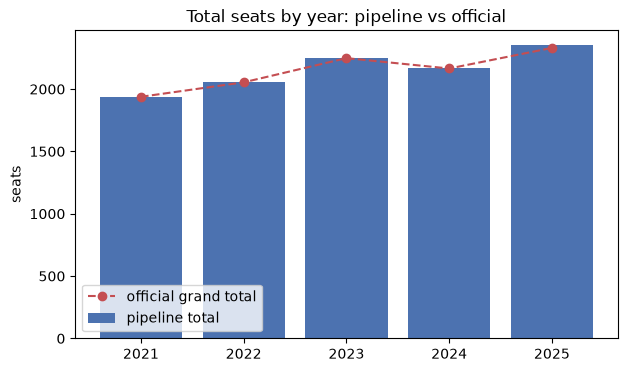

In [3]:
years_list = sorted(totals_by_year)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(years_list, [totals_by_year[y] for y in years_list], color='#4C72B0', label='pipeline total')
ax.plot(years_list, [OFFICIAL_TOTAL.get(y) for y in years_list], 'o--', color='#C44E52', label='official grand total')
ax.set_ylabel('seats')
ax.set_title('Total seats by year: pipeline vs official')
ax.legend()
plt.show()


## Seats by year x location (region)

Locations uppercased for display, matching the specialty/institution convention.

In [4]:
by_year_region = defaultdict(lambda: defaultdict(int))
regions_seen = set()
for r in vagas:
    key = (r['region_key'] or 'UNMAPPED').upper()
    by_year_region[r['year']][key] += int(r['seats'])
    regions_seen.add(key)

regions_sorted = sorted(regions_seen)
header = 'YEAR'.ljust(6) + ''.join(reg.ljust(16) for reg in regions_sorted)
print(header)
for year in sorted(by_year_region):
    row = year.ljust(6) + ''.join(str(by_year_region[year].get(reg, 0)).ljust(16) for reg in regions_sorted)
    print(row)


YEAR  ACORES          ALENTEJO        ALGARVE         CENTRO          LISBOA-VALE-TEJOMADEIRA         NORTE           UNMAPPED        
2021  35              55              61              348             687             35              653             64              
2022  45              61              60              353             732             37              693             73              
2023  29              45              45              271             586             39              561             672             
2024  0               69              111             372             699             48              734             132             
2025  50              90              87              408             811             70              837             0               


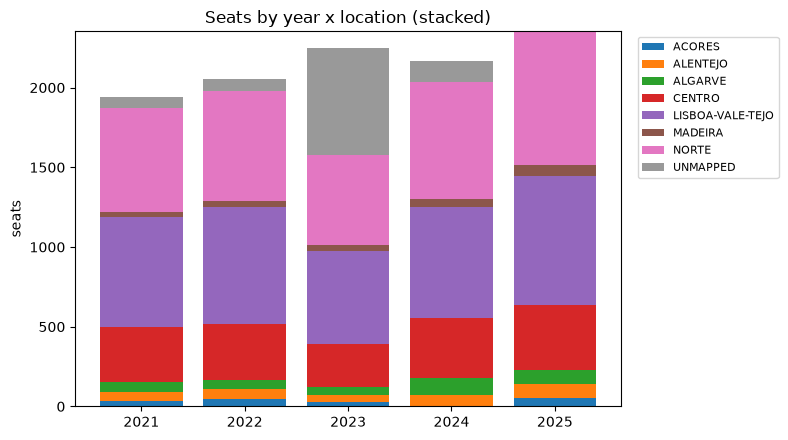

In [5]:
regions_no_unmapped = [r for r in regions_sorted if r != 'UNMAPPED'] + (['UNMAPPED'] if 'UNMAPPED' in regions_sorted else [])
bottoms = [0] * len(by_year_region)
fig, ax = plt.subplots(figsize=(8, 4.5))
for reg in regions_no_unmapped:
    vals = [by_year_region[y].get(reg, 0) for y in sorted(by_year_region)]
    color = '#999999' if reg == 'UNMAPPED' else None
    ax.bar(sorted(by_year_region), vals, bottom=bottoms, label=reg, color=color)
    bottoms = [b + v for b, v in zip(bottoms, vals)]
ax.set_ylabel('seats')
ax.set_title('Seats by year x location (stacked)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


## Unmapped-region rate by year

`region_key` is blank when `backend/region_mapping.py` couldn't match the raw region text (see its `REGION_KEYS` patterns). A high rate means real seats are invisible to the map/region filter in the UI, not that they don't exist.

In [6]:
for year in sorted(totals_by_year):
    unmapped = sum(int(r['seats']) for r in vagas if r['year'] == year and not r['region_key'])
    total = totals_by_year[year]
    pct = 100 * unmapped / total if total else 0
    flag = '  <-- HIGH' if pct > 20 else ''
    print(f"{year}: {unmapped:>5} / {total:>5} seats unmapped ({pct:5.1f}%){flag}")


2021:    64 /  1938 seats unmapped (  3.3%)
2022:    73 /  2054 seats unmapped (  3.6%)
2023:   672 /  2248 seats unmapped ( 29.9%)  <-- HIGH
2024:   132 /  2165 seats unmapped (  6.1%)
2025:     0 /  2353 seats unmapped (  0.0%)


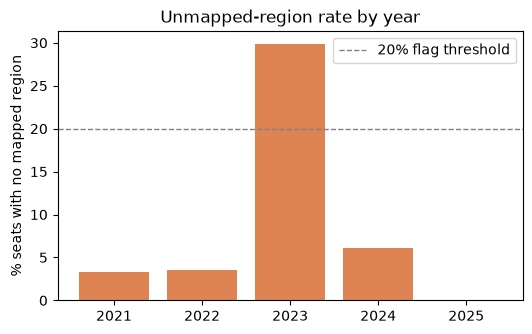

In [7]:
pct_by_year = {}
for year in sorted(totals_by_year):
    unmapped = sum(int(r['seats']) for r in vagas if r['year'] == year and not r['region_key'])
    pct_by_year[year] = 100 * unmapped / totals_by_year[year] if totals_by_year[year] else 0

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(list(pct_by_year), list(pct_by_year.values()), color='#DD8452')
ax.axhline(20, color='gray', linestyle='--', linewidth=1, label='20% flag threshold')
ax.set_ylabel('% seats with no mapped region')
ax.set_title('Unmapped-region rate by year')
ax.legend()
plt.show()


Down to single digits for 2021/2022/2024 after fixing a mis-captured column-header fragment (was being read as a bogus "region", see `backend/extract_vagas_labeled.py`'s `PAGE_BOILERPLATE`) and adding the "RAM"/"RAA" region acronyms to `backend/region_mapping.py`. **2023's ~30% is now isolated to exactly two specialties** (Medicina Geral e Familiar, Saúde Pública) that have zero region breakdown captured for that year -- a genuine gap in `extract_vagas.py`'s native-text parser for those two specialties' unusual table structure that year, not a name-matching issue. If you can point to how those two specialties' region rows are laid out in `vagas-2023.pdf` specifically, that's the next concrete fix.

## Specialty drift across years

Specialties present in some years but absent in others -- could be real (a specialty added/retired) or a canonicalization miss (see `backend/specialty_mapping.py`).

In [8]:
years_sorted = sorted(totals_by_year)
specialty_years = defaultdict(set)
for r in vagas:
    specialty_years[r['specialty']].add(r['year'])

all_years = set(years_sorted)
drifted = {s: yrs for s, yrs in specialty_years.items() if yrs != all_years}
print(f"{len(drifted)} / {len(specialty_years)} specialties are NOT present in every year:\n")
for s in sorted(drifted):
    missing = sorted(all_years - drifted[s])
    print(f"  {s:55s} missing: {missing}")


4 / 48 specialties are NOT present in every year:

  CIRURGIA PLÁSTICA, RECONSTRUTIVA E ESTÉTICA             missing: ['2024', '2025']
  MEDICINA DESPORTIVA                                     missing: ['2021']
  MEDICINA DO TRABALHO                                    missing: ['2024']
  MEDICINA FÍSICA E DE REABILITAÇÃO                       missing: ['2021', '2022', '2024']


Most gaps trace to years that never got full institution-level parsing for that specialty rather than the specialty not being offered -- cross-check any single-year-missing specialty against that year's `data/processed/extracted_text/vagas-YYYY.txt` before concluding it was really discontinued.

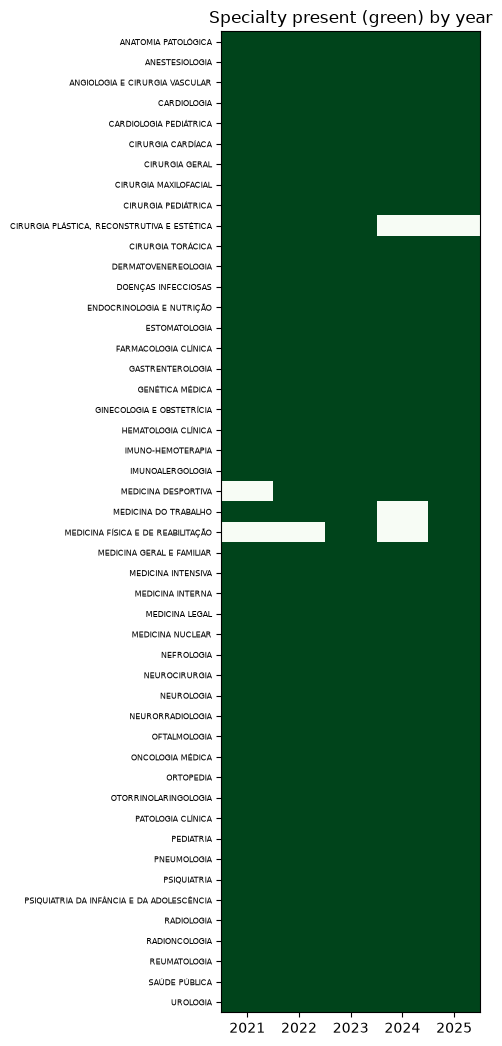

In [9]:
import numpy as np

specs_sorted = sorted(specialty_years)
matrix = np.array([[1 if y in specialty_years[s] else 0 for y in years_sorted] for s in specs_sorted])

fig, ax = plt.subplots(figsize=(5, max(6, len(specs_sorted) * 0.22)))
ax.imshow(matrix, aspect='auto', cmap='Greens', vmin=0, vmax=1)
ax.set_xticks(range(len(years_sorted)))
ax.set_xticklabels(years_sorted)
ax.set_yticks(range(len(specs_sorted)))
ax.set_yticklabels(specs_sorted, fontsize=6)
ax.set_title('Specialty present (green) by year')
plt.tight_layout()
plt.show()
